In [8]:
# %%
from IPython.display import clear_output
from matplotlib import cm, colors
import numpy as np
from numpy import pi
from scipy.optimize import fsolve
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import tqdm
L_b = 0.3185						# beam length [m]
w_p = 10e-3						# patch width [m]
w_s = 0.265625e-3					# spacing between patches [m]
Q = 31								# number of unit cells
S = Q								# one patch per cell
# positions

xL = np.array([(j-1)*w_p + j*w_s for j in range(1, S+1)], dtype=float)
xR = xL + w_p
eps0 = 8.854e-12
eps_r = 1900.0

d31 = -1.75e-10
s11 = 1.5873e-11
e31 = d31 / s11   
# print(f"e31ff = {e31:e} C/m^2")
eps33_bar = eps0 * eps_r
eps33 = eps33_bar - d31**2 / s11
# print(f"eps33_bar = {eps33_bar:e} F/m")

#  ===================== Beam material (6061 Al) =====================
rho_p, rho_s = 7600, 2700          # [kg/m³]
E_p, E_s   = 1/s11, 70e9           # [Pa]						# Pa
b = 10e-3						# m
# hp, hs = 0.31e-3, 0.607e-3 					# m
hp, hs = 0.252e-3, 0.51e-3 		
hpc = (hp + hs)/2
#===================================Stiffness==========================
m = b*(rho_s * hs + 2 * rho_p * hp)
term1 = E_s * hs**3 / 8
term2 = E_p * ((hp + hs/2)**3 - hs**3/8)
YI = 2*b/3 * (term1 + term2)
# e31 = -14.76 #-5.4e-10						# C/m^2 (typical for PZT-5A)
# e31, eps33 = -14.76, 14.8e-9   

# A_term = (hp + 0.5*hs)**2 - (hs**2)/4.0
Cp_scalar = 2*eps33*  w_p * b / hp
# Cp = Cp_scalar * np.ones(S)
theta_mech = 2*e31 * b *hpc		# parallel case (3.9)
xL = np.array([(j-1)*w_p + j*w_s for j in range(1, S+1)], dtype=float)
xR = xL + w_p
segments = []

# Initial gap
if xL[0] > 0:
    segments.append(("gap", 0.0, xL[0]))

# Patch-gap alternating sequence
for j in range(S):
    # Patch j
    segments.append(("patch", xL[j], xR[j]))

    # Gap after patch j (if not last)
    if j < S-1 and xR[j] < xL[j+1]:
        segments.append(("gap", xR[j], xL[j+1]))

# Final gap
if xR[-1] < L_b:
    segments.append(("gap", xR[-1], L_b))
n_el_patch = 4
n_el_gap   = 2
x_nodes = [0.0]

for seg_type, xa, xb in segments:
    if seg_type == "patch":
        n = n_el_patch
    else:
        n = n_el_gap

    xs = np.linspace(xa, xb, n+1)

    # Skip first node to avoid duplication
    x_nodes.extend(xs[1:])
x_nodes = np.array(x_nodes)
Nnodes = len(x_nodes)
elements = [(i, i+1) for i in range(Nnodes-1)]
elem_type = []

for (i, j) in elements:
    xm = 0.5 * (x_nodes[i] + x_nodes[j])

    # Check if midpoint is inside any patch
    in_patch = any((xm >= xL[k]) and (xm <= xR[k]) for k in range(S))

    elem_type.append("patch" if in_patch else "gap")
rhoA_elem = []
EI_elem   = []

rhoA_patch = b * (rho_s * hs + 2 * rho_p * hp)
rhoA_gap   = b * rho_s * hs


EI_patch = YI
EI_gap   = E_s * b * hs**3 / 12

# rhoA_gap = rhoA_patch
# EI_gap = EI_patch

for t in elem_type:
    if t == "patch":
        rhoA_elem.append(rhoA_patch)
        EI_elem.append(EI_patch)
    else:
        rhoA_elem.append(rhoA_gap)
        EI_elem.append(EI_gap)
assert all(any(abs(x - xL[k]) < 1e-12 or abs(x - xR[k]) < 1e-12
               for k in range(S)) for x in x_nodes if x in np.concatenate((xL, xR)))
assert abs(x_nodes[-1] - L_b) < 1e-12
assert np.all(np.diff(x_nodes) > 0)

Ndof = 2 * Nnodes
K = np.zeros((Ndof, Ndof))

for e, (i, j) in enumerate(elements):

    Le = x_nodes[j] - x_nodes[i]
    EI = EI_elem[e]

    Ke = (EI / Le**3) * np.array([
        [ 12,      6*Le,   -12,      6*Le ],
        [ 6*Le,  4*Le**2,  -6*Le,   2*Le**2 ],
        [ -12,    -6*Le,    12,     -6*Le ],
        [ 6*Le,  2*Le**2,  -6*Le,   4*Le**2 ]
    ])

    dofs = [
        2*i,     # w_i
        2*i + 1, # theta_i
        2*j,     # w_j
        2*j + 1  # theta_j
    ]

    # Assemble
    for a in range(4):
        for b in range(4):
            K[dofs[a], dofs[b]] += Ke[a, b]
M = np.zeros((Ndof, Ndof))

for e, (i, j) in enumerate(elements):

    Le = x_nodes[j] - x_nodes[i]
    rhoA = rhoA_elem[e]

    Me = (rhoA * Le / 420.0) * np.array([
        [156,       22*Le,     54,       -13*Le],
        [22*Le,   4*Le**2,   13*Le,    -3*Le**2],
        [54,        13*Le,    156,       -22*Le],
        [-13*Le, -3*Le**2,  -22*Le,     4*Le**2]
    ])

    dofs = [
        2*i,       # w_i
        2*i + 1,   # theta_i
        2*j,       # w_j
        2*j + 1    # theta_j
    ]

    for a in range(4):
        for b in range(4):
            M[dofs[a], dofs[b]] += Me[a, b]
# ===================== Electromechanical coupling matrix =====================

# S = len(xL)                     # number of patches
Gamma = np.zeros((Ndof, S))     # coupling matrix Γ

# map node coordinate -> node index
node_index = {x: i for i, x in enumerate(x_nodes)}

for j in range(S):

	# node indices at patch edges
	kL = node_index[xL[j]]
	kR = node_index[xR[j]]

	# rotation DOFs
	dof_theta_L = 2 * kL + 1
	dof_theta_R = 2 * kR + 1

	# Γ entries
	Gamma[dof_theta_R, j] +=  theta_mech
	Gamma[dof_theta_L, j] += -theta_mech
# each column must have exactly two nonzeros
assert np.all(np.sum(Gamma != 0, axis=0) == 2)

fixed_dofs = [0, 1]  # w_0 = 0, theta_0 = 0

all_dofs = np.arange(Ndof)
free_dofs = np.setdiff1d(all_dofs, fixed_dofs)

K_full = K.copy()
M_full = M.copy()
K_full = K.copy()
M_full = M.copy()
K_red = K_full[np.ix_(free_dofs, free_dofs)]
M_red = M_full[np.ix_(free_dofs, free_dofs)]
Gamma_red = Gamma[free_dofs, :]
import numpy as np
j_exc = 30
N = M_red.shape[0]			# mechanical DOFs
S = Gamma_red.shape[1]		# electrical DOFs

idx_all = np.arange(S)
idx_f = np.delete(idx_all, j_exc)
Gamma_f = Gamma_red[:, idx_f]        # (N, S-1)
Gamma_e = Gamma_red[:, j_exc]        # (N,)
M_mech = M_red
A_exc = 50
f0 = 1e3
f1 = 2e3
t_end = 0.2
def v_exc(t, A_exc=A_exc, f0=f0, f1=f1, t_end=t_end):
	return A_exc*np.sin(2*np.pi*(f0+ t*(f1-f0)/t_end) *t)
R_c = 1e3; K_p = 0.02; K_i = 0.0; K_c = 0
C_beta  = 9.608236915808987e-08*3
C_alpha = 5.837701779879474
D =  C_alpha * M_red + C_beta * K_red
M_elec = Cp_scalar * np.eye(len(idx_f))
M_ODE = np.block([
	[M_mech,					np.zeros((N, len(idx_f)))],
	[np.zeros((len(idx_f), N)),	M_elec]
])
C_ODE = np.block([
	[D,					-Gamma_f],
	[Gamma_f.T,	(K_p/R_c)*np.eye(len(idx_f))]
])


def f_int(x):
	u = x[:N]
	qf = x[N:]

	fu = K_red @ u
	fq = (K_i/R_c)*qf + (K_c/R_c)*qf**3

	return np.concatenate((fu, fq))
def K_tan(x):
	qf = x[N:]

	Kqq = (K_i/R_c)*np.eye(len(qf)) \
		+ (3*K_c/R_c)*np.diag(qf**2)

	return np.block([
		[K_red,					np.zeros((N, len(qf)))],
		[np.zeros((len(qf), N)),	Kqq]
	])
def f_ext(t):
	fu = Gamma_e * v_exc(t)
	fq = np.zeros(len(idx_f))
	return np.concatenate((fu, fq))



In [ ]:
nt = u.shape[0]
t = np.arange(nt) * dt

# choose a mechanical DOF to visualize
# i_mech = np.argmax(np.std(u, axis=0))   # automatic choice
i_mech = 101
plt.figure(figsize=(7,4))
plt.plot(t, u[:, i_mech], label=f"u[{i_mech}]")
plt.xlabel("Time [s]")
plt.ylabel("Displacement")
plt.title("Mechanical response (Newmark)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



In [3]:
Nmodes

376

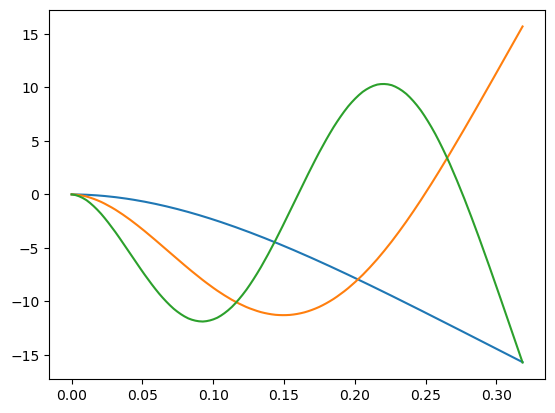

In [2]:
from FE1 import PiezoBeamFE
import numpy as np
import sys
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.linalg import eigh
project_root = Path.cwd().parents[0]
sys.path.append(str(project_root))
from beam_properties import PiezoBeamParams

params = PiezoBeamParams()
hp, hs = 0.252e-3, 0.51e-3 		
params.hp = hp; params.hs = hs
fe = PiezoBeamFE(params)
freq, omega, Phi = fe.eigen_analysis()
x_nodes = fe.x_nodes
Ndof = fe.Ndof
# assert np.linalg.norm(K - K.T) < 1e-10
# eigvals = np.linalg.eigvalsh(K_red)
# assert np.all(eigvals > 0)

# from scipy.linalg import eigh

# eigvals, eigvecs = eigh(K_red, M_red)
# omega = np.sqrt(eigvals)        # rad/s
# freq  = omega / (2*np.pi)       # Hz
# idx = np.argsort(freq)
# freq = freq[idx]
# eigvecs = eigvecs[:, idx]
# Nmodes = len(freq)
# Phi = np.zeros((Ndof, Nmodes))

# for i in range(Nmodes):
#     Phi[free_dofs, i] = eigvecs[:, i]
# for i in range(Nmodes):
#     norm = np.sqrt(Phi[:, i].T @ M @ Phi[:, i])
#     Phi[:, i] /= norm
# print(freq[:5])
# Phi.T @ M @ Phi   # ≈ identity
# Phi.T @ K @ Phi   # ≈ diag(ω²)
w_dofs = np.arange(0, Ndof, 2)

for i in range(3):
    w_mode = Phi[w_dofs, i]
    plt.plot(x_nodes, w_mode, label=f"Mode {i+1}")


In [ ]:

ndof = N + len(idx_f)
x0 = np.zeros(ndof)
x_dot0 = np.zeros(ndof)
a0 = np.linalg.solve(
	M,
	f_ext(0.0) - C @ x_dot0 - f_int(x0)
)
dt = 1/f1/20			# example – use what you had before
n_steps = int(t_end / dt)
beta = 0.25
gamma = 0.5
from newmark import newmark_beta_nonlinear
x, x_dot, x_ddot = newmark_beta_nonlinear(
	M=M,
	C=C,
	f_int=f_int,
	K_tan=K_tan,
	f_ext=f_ext,
	u0=x0,
	v0=x_dot0,
	a0_init=a0,
	dt=dt,
	n_steps=n_steps,
	beta=beta,
	gamma=gamma,
	newton_tol=1e-9,
	newton_maxiter=5
)
u = x[:, :N]
u_dot = x_dot[:, :N]
u_ddot = x_ddot[:, :N]
qf = x[:, N:]
qf_dot = x_dot[:, N:]


In [ ]:
import Reduced_order.ROM_v1
np.linalg.cond(M_red)


Eigenfrequency comparison (uniform beam)
Mode | f_COMSOL [Hz] | f_FE [Hz] | f_ROM [Hz]
------------------------------------------------
   1 |        5.3055 |    5.3192 |    5.6954
   2 |       33.2420 |   33.3350 |   35.6927
   3 |       93.0660 |   93.3316 |   99.9405
   4 |      182.3600 |  182.8804 |  195.8434
   5 |      301.4500 |  302.2951 |  323.7432
   6 |      450.3300 |  451.5504 |  483.6163
   7 |      629.0300 |  630.6448 |  675.4642
   8 |      837.5900 |  839.5764 |  899.2866
   9 |     1076.0000 | 1078.3444 | 1155.0837
  10 |     1344.4000 | 1346.9484 | 1442.8554
  11 |     1642.8000 | 1645.3881 | 1762.6017
  12 |     1971.1000 | 1973.6626 | 2114.3227
  13 |     2329.5000 | 2331.7700 | 2498.0183
  14 |     2717.8000 | 2719.7061 | 2913.6886
  15 |     3136.2000 | 3137.4629 | 3361.3335
  16 |     3584.5000 | 3585.0264 | 3840.9530
  17 |     4062.8000 | 4062.3736 | 4352.5472
  18 |     4570.8000 | 4569.4678 | 4896.1160
  19 |     5108.4000 | 5106.2524 | 5471.6594
  20 |  

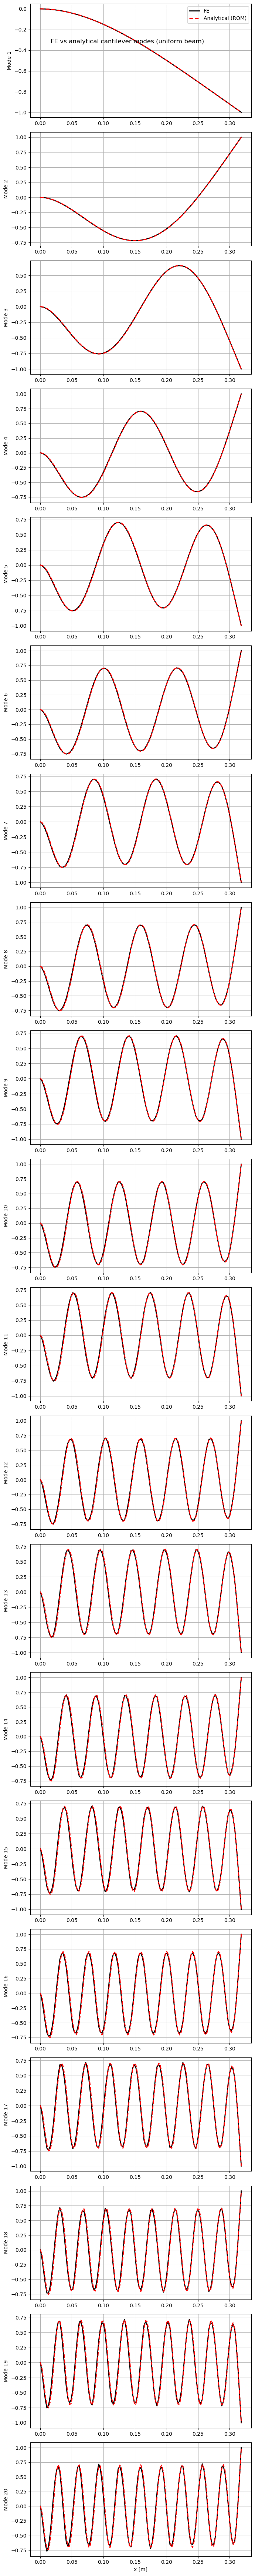


Modal Assurance Criterion (MAC)
Mode 1: MAC = 0.999997
Mode 2: MAC = 0.999972
Mode 3: MAC = 0.999905
Mode 4: MAC = 0.999788
Mode 5: MAC = 0.999617
Mode 6: MAC = 0.999384
Mode 7: MAC = 0.999084
Mode 8: MAC = 0.998710
Mode 9: MAC = 0.998257
Mode 10: MAC = 0.997718
Mode 11: MAC = 0.997087
Mode 12: MAC = 0.996357
Mode 13: MAC = 0.995522
Mode 14: MAC = 0.994575
Mode 15: MAC = 0.993509
Mode 16: MAC = 0.992315
Mode 17: MAC = 0.990987
Mode 18: MAC = 0.989513
Mode 19: MAC = 0.987882
Mode 20: MAC = 0.986078


In [4]:
# %%
import sys
from pathlib import Path

# --------------------------------------------------
# add project root to Python path
# --------------------------------------------------
project_root = Path.cwd().parents[0]
sys.path.append(str(project_root))

# --------------------------------------------------
# ROM imports (UPDATED)
# --------------------------------------------------
from Reduced_order.ROM import ROM
from beam_properties import PiezoBeamParams

# --------------------------------------------------
# standard imports
# --------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# FE vs analytical verification: mode shapes + eigenfrequencies
# ============================================================

# ----------------------------
# user settings
# ----------------------------
Nmodes_check = 20			# number of modes to compare
x_plot = x_nodes			# FE nodal coordinates
w_dofs = np.arange(0, Ndof, 2)		# transverse DOFs

# ----------------------------
# instantiate parameters + ROM
# ----------------------------
params = PiezoBeamParams()
rom = ROM(params, N=Nmodes_check)

# ----------------------------
# FE frequencies
# ----------------------------
f_fe = freq[:Nmodes_check]

# ----------------------------
# analytical frequencies (ROM-based)
# ----------------------------
omega_ana = rom.omega[:Nmodes_check]
f_ana = omega_ana / (2*np.pi)

# ----------------------------
# COMSOL reference frequencies
# ----------------------------
f_comsol = np.array([
	5.3055, 33.242, 93.066, 182.36, 301.45, 450.33, 629.03, 837.59,
	1076.0, 1344.4, 1642.8, 1971.1, 2329.5, 2717.8, 3136.2,
	3584.5, 4062.8, 4570.8, 5108.4, 5675.4, 6271.4, 6895.9, 7141.3
])

# ----------------------------
# frequency comparison table
# ----------------------------
print("\nEigenfrequency comparison (uniform beam)")
print("Mode | f_COMSOL [Hz] | f_FE [Hz] | f_ROM [Hz]")
print("------------------------------------------------")
for r in range(Nmodes_check):
	print(f"{r+1:4d} | {f_comsol[r]:13.4f} | {f_fe[r]:9.4f} | {f_ana[r]:9.4f}")

# ----------------------------
# mode shape comparison + MAC
# ----------------------------
MAC = np.zeros(Nmodes_check)

# consistent transverse mass matrix
Mw = fe.M[np.ix_(w_dofs, w_dofs)]

plt.figure(figsize=(7, 3.5*Nmodes_check))

for r in range(Nmodes_check):

	# FE transverse mode
	w_fe = Phi[w_dofs, r].copy()

	# analytical transverse mode (ROM)
	w_ana = rom.mode_shape(r, x_plot)

	# sign consistency
	if np.dot(w_fe, w_ana) < 0.0:
		w_ana *= -1.0

	# normalize by max amplitude (visual comparison)
	w_fe /= np.max(np.abs(w_fe))
	w_ana /= np.max(np.abs(w_ana))

	# MAC computation
	num = np.abs(w_fe @ Mw @ w_ana)**2
	den = (w_fe @ Mw @ w_fe) * (w_ana @ Mw @ w_ana)
	MAC[r] = num / den

	# plot
	plt.subplot(Nmodes_check, 1, r+1)
	plt.plot(x_plot, w_fe, 'k-', lw=2, label='FE')
	plt.plot(x_plot, w_ana, 'r--', lw=2, label='Analytical (ROM)')
	plt.ylabel(f"Mode {r+1}")
	plt.grid(True)

	if r == 0:
		plt.legend()

plt.xlabel("x [m]")
plt.suptitle("FE vs analytical cantilever modes (uniform beam)", y=0.98)
plt.tight_layout()
plt.show()

# ----------------------------
# MAC summary
# ----------------------------
print("\nModal Assurance Criterion (MAC)")
for r in range(Nmodes_check):
	print(f"Mode {r+1}: MAC = {MAC[r]:.6f}")


In [ ]:
from scipy.linalg import cho_factor, cho_solve
from scipy.integrate import solve_ivp
from scipy.sparse import csr_matrix
N = Ndof - 2
M_red     = csr_matrix(M_red)
K_red     = csr_matrix(K_red)
Gamma_red = csr_matrix(Gamma_red)

# mechanical mass factorization (SPD)
# M_factor = cho_factor(M_red)

# def apply_Minv(rhs):
# 	return cho_solve(M_factor, rhs)

from scipy.sparse.linalg import splu

M_factor = splu(M_red.tocsc())   # factor once

def apply_Minv(rhs):
	return M_factor.solve(rhs)




rhs_u = np.zeros(N)
rhs_q = np.zeros(S)
# def odefun(t, x, v_exc=v_exc, K_c=0, K_p=0, K_i=0):
# 	N = Ndof - 2
# 	u = x[0:N]
# 	u_dot = x[N:2*N]
# 	q = x[2*N:2*N+S]
# 	q_dot = x[2*N+S:2*N+2*S]
# 	q_dot[j_exc] = v_exc(t)
# 	# Ku   = K_red.dot(u)
# 	# Du   = D.dot(u_dot)          # D should also be sparse!
# 	# Gq   = Gamma_red.dot(q_dot)
# 	# rhs_u = Ku + Du - Gq
# 	rhs_u[:] = K_red.dot(u)
# 	rhs_u += D.dot(u_dot)
# 	rhs_u -= Gamma_red.dot(q_dot)
# 	u_ddot = -apply_Minv(rhs_u)
# 	# u_ddot = -apply_Minv(rhs_u)
# 	# u_ddot = -apply_Minv(K_red @ u + D @ u_dot - Gamma_red @ q_dot)
# 	# u_ddot = -np.linalg.solve(M_red, K_red @ u + D @ u_dot - Gamma_red @ q_dot)
# 	q_ddot = -(K_i/R_c * q_dot + K_i/R_c * q + Gamma_red.T @ u_dot)/Cp		
# 	return np.concatenate([u_dot, u_ddot, q_dot, q_ddot])
def make_odefun():
	rhs_u = np.zeros(N)
	rhs_q = np.zeros(S)
	def odefun(t, x):
		
		u = x[0:N]
		u_dot = x[N:2*N]
		q = x[2*N:2*N+S]
		q_dot = x[2*N+S:2*N+2*S]

		q_dot[j_exc] = v_exc(t)

		# mechanical RHS
		rhs_u[:]  = K_red.dot(u)
		rhs_u[:]   += D.dot(u_dot)
		rhs_u[:]   -= Gamma_red.dot(q_dot)
		u_ddot    = -apply_Minv(rhs_u)

		# electrical RHS
		rhs_q[:]  = Gamma_red.T.dot(u_dot)
		rhs_q[:]   += (K_i/R_c) *  q
		rhs_q[:]   += (K_c/R_c) *  q**3
		rhs_q[:]   += (K_p/R_c) * q_dot 

		q_ddot    = -rhs_q / Cp
		return np.concatenate((u_dot, u_ddot, q_dot, q_ddot))
	
	return odefun
# initial conditions
x0 = np.zeros(2*(Ndof-2) + 2*S)

t_span = (0.0, t_end)
t_eval = np.arange(0.0, t_end, 1/f1/20)
odefun = make_odefun()
sol = solve_ivp(
	odefun,
	t_span,
	x0,
	t_eval=t_eval,
	method="BDF",
	rtol=1e-6,
	atol=1e-9
)


In [ ]:
import numpy as np
import time
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import splu

# ============================================================
# ASSUMES THESE ALREADY EXIST IN YOUR SESSION:
#   M_red, K_red, D, Gamma_red
# ============================================================

N = M_red.shape[0]
S = Gamma_red.shape[1]

print(f"N = {N}, S = {S}")

# ============================================================
# DENSE SETUP
# ============================================================

M_dense = M_red.copy()
K_dense = K_red.copy()
D_dense = D.copy()
G_dense = Gamma_red.copy()

# pre-factorize dense mass matrix
# M_dense_inv = np.linalg.inv(M_dense)
M_dense_inv = cho_factor(M_dense)

def Minv_dense(rhs):
	return cho_solve(M_dense_inv, rhs)

# ============================================================
# SPARSE SETUP
# ============================================================

M_sp = csr_matrix(M_red)
K_sp = csr_matrix(K_red)
D_sp = csr_matrix(D)
G_sp = csr_matrix(Gamma_red)

# sparse LU (once)
M_sp_fact = splu(M_sp.tocsc())

def Minv_sparse(rhs):
	return M_sp_fact.solve(rhs)


# ============================================================
# RANDOM TEST VECTORS (same for both)
# ============================================================

u     = np.random.randn(N)
u_dot = np.random.randn(N)
q_dot = np.random.randn(S)

rhs = np.zeros(N)

NREP = 3000   # increase if timing is noisy

# ============================================================
# DENSE TIMING
# ============================================================

t0 = time.perf_counter()
for _ in range(NREP):
	rhs[:]  = K_dense @ u
	rhs[:] += D_dense @ u_dot
	rhs[:] -= G_dense @ q_dot
	u_ddot = -Minv_dense(rhs)
t_dense = time.perf_counter() - t0

# ============================================================
# SPARSE TIMING
# ============================================================

t0 = time.perf_counter()
for _ in range(NREP):
	rhs[:]  = K_sp.dot(u)
	rhs[:] += D_sp.dot(u_dot)
	rhs[:] -= G_sp.dot(q_dot)
	u_ddot = -Minv_sparse(rhs)
t_sparse = time.perf_counter() - t0

# ============================================================
# RESULTS
# ============================================================

print("\n===== BENCHMARK RESULTS =====")
print(f"Dense time   : {t_dense:.6f} s")
print(f"Sparse time  : {t_sparse:.6f} s")
print(f"Speedup      : {t_dense / t_sparse:.2f} ×")

print("\n===== SPARSITY INFO =====")
print(f"nnz(M) = {M_sp.nnz}  ({100*M_sp.nnz/(N*N):.3f} %)")
print(f"nnz(K) = {K_sp.nnz}  ({100*K_sp.nnz/(N*N):.3f} %)")
print(f"nnz(G) = {G_sp.nnz}")


In [ ]:
import numpy as np
import time
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import splu, cg, LinearOperator

# ============================================================
# ASSUMES THESE ALREADY EXIST IN YOUR SESSION:
#   M_red, K_red, D, Gamma_red
# ============================================================

N = M_red.shape[0]
S = Gamma_red.shape[1]

print(f"N = {N}, S = {S}")

# ============================================================
# COMMON TEST DATA
# ============================================================

u     = np.random.randn(N)
u_dot = np.random.randn(N)
q_dot = np.random.randn(S)

rhs = np.zeros(N)
NREP = 3000

# ============================================================
# DENSE METHODS
# ============================================================

M_dense = M_red.copy()
K_dense = K_red.copy()
D_dense = D.copy()
G_dense = Gamma_red.copy()

# Dense inverse (best possible dense baseline)
M_dense_inv = np.linalg.inv(M_dense)

def Minv_dense_inv(rhs):
	return M_dense_inv @ rhs

# Dense solve (worst dense practice)
def Minv_dense_solve(rhs):
	return np.linalg.solve(M_dense, rhs)

# ============================================================
# SPARSE DIRECT (LU)
# ============================================================

M_sp = csr_matrix(M_red)
K_sp = csr_matrix(K_red)
D_sp = csr_matrix(D)
G_sp = csr_matrix(Gamma_red)

M_lu = splu(M_sp.tocsc())

def Minv_sparse_lu(rhs):
	return M_lu.solve(rhs)

# ============================================================
# SPARSE ITERATIVE (CG + JACOBI PRECONDITIONER)
# ============================================================

M_diag = M_sp.diagonal()
M_diag_inv = 1.0 / M_diag

def jacobi_prec(v):
	return M_diag_inv * v

P = LinearOperator(M_sp.shape, matvec=jacobi_prec)

def Minv_sparse_cg(rhs):
	x, info = cg(
		M_sp, rhs,
		M=P,
		rtol=1e-8,
		atol=0.0,
		maxiter=200
	)
	if info != 0:
		raise RuntimeError(f"CG did not converge (info={info})")
	return x

# ============================================================
# LUMPED MASS (DIAGONAL)
# ============================================================

M_lumped = np.array(M_sp.sum(axis=1)).ravel()
M_lumped_inv = 1.0 / M_lumped

def Minv_lumped(rhs):
	return M_lumped_inv * rhs

# ============================================================
# BENCHMARK FUNCTION
# ============================================================

def benchmark(Minv):
	t0 = time.perf_counter()
	for _ in range(NREP):
		rhs[:]  = K_sp.dot(u)
		rhs[:] += D_sp.dot(u_dot)
		rhs[:] -= G_sp.dot(q_dot)
		u_ddot = -Minv(rhs)
	return time.perf_counter() - t0

# ============================================================
# RUN BENCHMARKS
# ============================================================

results = {}

results["Dense inverse"] = benchmark(Minv_dense_inv)
results["Dense solve"]   = benchmark(Minv_dense_solve)
results["Sparse LU"]     = benchmark(Minv_sparse_lu)

# CG may still fail for very ill-conditioned systems; keep isolated
try:
	results["Sparse CG (Jacobi)"] = benchmark(Minv_sparse_cg)
except RuntimeError as e:
	results["Sparse CG (Jacobi)"] = np.nan
	print("CG failed:", e)

results["Lumped mass"] = benchmark(Minv_lumped)

# ============================================================
# REPORT RESULTS
# ============================================================

print("\n===== MASS MATRIX SOLVE BENCHMARK =====")
valid_times = [v for v in results.values() if np.isfinite(v)]
best = min(valid_times)

for k, v in results.items():
	if np.isfinite(v):
		print(f"{k:20s}: {v:.6f} s   ({v/best:.2f}×)")
	else:
		print(f"{k:20s}: failed")

print("\n===== SPARSITY INFO =====")
print(f"nnz(M) = {M_sp.nnz}  ({100*M_sp.nnz/(N*N):.4f} %)")
print(f"nnz(K) = {K_sp.nnz}  ({100*K_sp.nnz/(N*N):.4f} %)")
print(f"nnz(G) = {G_sp.nnz}")
